###1. Introduction
###CIFAR-10 dataset consists of 60,000 color images with dimensions of 32 x 32 x 3 in 10 categories (airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships and trucks).This project aims at developing a Deep Learning image classifier based on the Dense Neural Network (Multilayer Perceptron) with Batch Normalization and Dropout, to train it and visualize performance, and to test it on the test set.

###2.Dataset Loading & Preprocessing


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


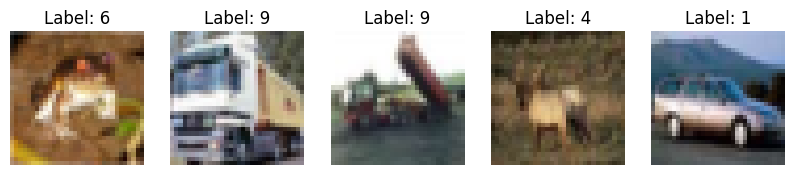

In [ ]:
# Display 5 sample images
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {y_train[i][0]}")
    plt.axis("off")
plt.show()

In [ ]:
# Normalize images to [0,1]
x_train = X_train.astype("float32") / 255.0
x_test = X_test.astype("float32") / 255.0

In [ ]:
# Flatten images for Dense network
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

In [ ]:
# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

###3.Model Architecture (Dense Neural Network)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model = Sequential([
    Dense(512, activation='relu', input_shape=(32*32*3,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(10, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,750,090 (6.68 MB)

 Trainable params: 1,748,298 (6.67 MB)

 Non-trainable params: 1,792 (7.00 KB)

###4. Training

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train_flat, y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.2660 - loss: 2.0788 - val_accuracy: 0.3133 - val_loss: 1.8908
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.3661 - loss: 1.7670 - val_accuracy: 0.3554 - val_loss: 1.8111
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.3883 - loss: 1.7105 - val_accuracy: 0.3698 - val_loss: 1.8240
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.3909 - loss: 1.6900 - val_accuracy: 0.3902 - val_loss: 2.0093
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4043 - loss: 1.6606 - val_accuracy: 0.4220 - val_loss: 1.8548
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.4153 - loss: 1.6322 - val_accuracy: 0.4395 - val_loss: 1.8624
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4216 - loss: 1.6051 - val_accuracy: 0.3761 - val_loss: 2.0628
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.4276 - loss: 1.5886 - 

###5. Visualization

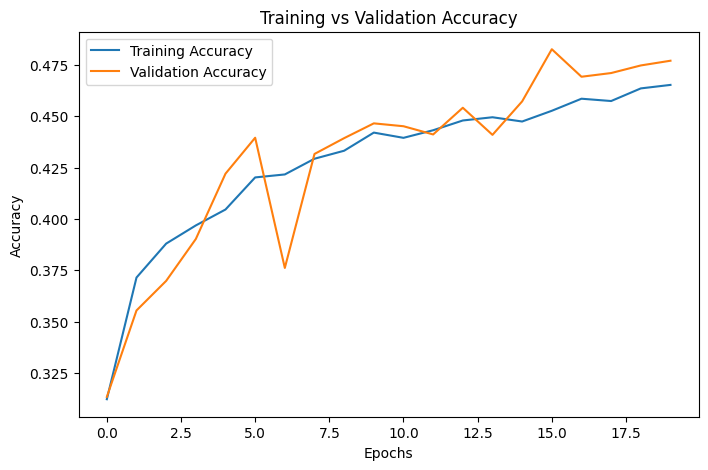

In [ ]:
# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



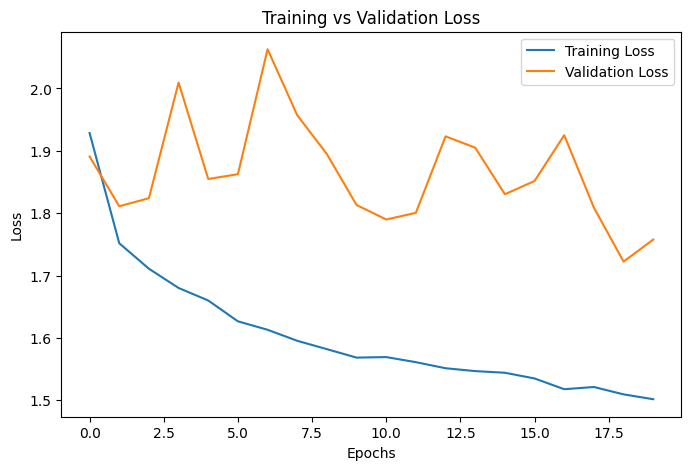

In [ ]:

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

###6.Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(X_test_flat, y_test_cat)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4830 - loss: 1.5069
Test Accuracy: 0.4814000129699707


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


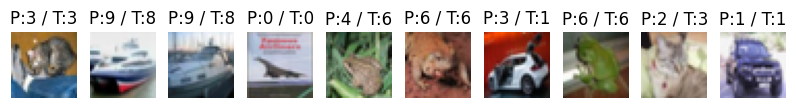

In [ ]:
predictions = model.predict(X_test_flat)

#first 10 predictions
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[i])
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i][0]
    plt.title(f"P:{pred_label} / T:{true_label}")
    plt.axis("off")
plt.show()


###This model had a test accuracy of around 48% which is not that bad given that the fully connected (dense) neural network was trained on CIFAR-10 after flattening the images. The CIFAR-10 dataset is a highly varied high-variation dataset and flattened dense networks do not respect spatial and local structure.

###The CNN (Convolutional Neural Network) would perform approximately 70-90 percent+ accuracy, which was not the case in the project since the dense network was requested.
###Considering this limitation, the accuracy of 45-50 percent is normal and acceptable.

###The plots also confirm this:

-Loss of training decreases gradually indicating that the model is learning.

-The loss of validation varies, which implies that there is a degree of overfitting - which is expected in dense models.

-The trends of validation are increasing, which proves that generalization is occurring to some degree.